In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import metrics
import shap
import warnings

warnings.filterwarnings("ignore")

rs = 42
np.random.seed(rs)
df = pd.read_excel("../../../data/ready_for_modeling_1.xlsx")
for x in ['religionAffiliation', 
          'specialDemographic', 
          'mergingInstitutionPopulation', 
          'mergingInstitutionType', 
          'mergingInstitutionLocationType', 
          'mergingInstitutionReligiousAffiliation',]:
    df[x] = df[x].fillna('None')
df['endowmentMedian'] = df['endowmentMedian'].fillna(-1)
df.drop(columns=['mergingInstitutionPopulation'], inplace=True)

colors_tab20 = cm['tab20'].resampled(20).colors
colors_tab20b = cm['tab20b'].resampled(20).colors
tab_colors = list(colors_tab20) + list(colors_tab20b)

df.head()

/Users/sepehrakbari/Projects/enrollment-cliff/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,name,yearEstablished,state,stateAbbreviation,locationType,locationTypeKind,typeOwned,typeProfit,level,hasUndergraduate,...,stateFourYearAppropriationsPerFTEMedian,stateTwoYearNetTuitionRevenuePerFTEMedian,stateFourYearNetTuitionRevenuePerFTEMedian,statePopulation18to24yoMedian,statePopulation25yoAndOverMedian,statePopulation18to24yoHighSchoolGradMedian,statePopulation25yoAndOverHighSchoolGradMedian,statePopulation18to24yoSomeCollegeOrHigherMedian,statePopulation25yoAndOverSomeCollegeOrHigherMedian,statePerCapitaPersonalIncomeMedian
0,Alderson Broaddus University,1871,West Virginia,WV,Rural,Distant,Private,Nonprofit,4-year,True,...,5634.822870,3552.459646,8324.661159,79926.5,612398.0,60470.5,512687.5,79926.5,612398.0,51075
1,Alliance University (Formerly Nyack College),1882,New York,NY,City,Large,Private,Nonprofit,4-year,True,...,14514.215742,4968.842112,7115.076497,1126667.0,8594351.5,497059.0,3517833.0,1126667.0,8594351.5,78501
2,Ancilla College,1937,Indiana,IN,Rural,Distant,Private,Nonprofit,2-year,True,...,6263.361828,3082.258414,12604.847801,337715.5,2531049.0,228011.0,1484195.5,337715.5,2531049.0,59797
3,Becker College,1784,Massachusetts,MA,City,Midsize,Private,Nonprofit,4-year,True,...,12392.121586,3823.431201,8164.798013,433897.0,3292373.5,194673.5,1135221.5,433897.0,3292373.5,85585
4,Bloomfield College,1868,New Jersey,NJ,Suburb,Large,Private,Nonprofit,4-year,True,...,10431.614347,3230.813658,11047.054665,469274.0,4014028.0,225395.0,1672783.5,469274.0,4014028.0,78329


combining reason of closures into a single feature

In [2]:
df.loc[df['name'].isin(['Independence University', 'Alliance University (Formerly Nyack College)']), 'reasonFinancial'] = True

reason_cols = ['reasonFinancial', 'reasonEnrollment', 'reasonPandemic', 'reasonMutualBenefit']
def create_reason_closure(row):
    reasons = [str(i) for i, reason in enumerate(reason_cols) if row[reason]]
    return ''.join(sorted(reasons)) if reasons else 'None'

df['reasonClosure'] = df.apply(create_reason_closure, axis=1)
df.head()

,name,yearEstablished,state,stateAbbreviation,locationType,locationTypeKind,typeOwned,typeProfit,level,hasUndergraduate,...,stateTwoYearNetTuitionRevenuePerFTEMedian,stateFourYearNetTuitionRevenuePerFTEMedian,statePopulation18to24yoMedian,statePopulation25yoAndOverMedian,statePopulation18to24yoHighSchoolGradMedian,statePopulation25yoAndOverHighSchoolGradMedian,statePopulation18to24yoSomeCollegeOrHigherMedian,statePopulation25yoAndOverSomeCollegeOrHigherMedian,statePerCapitaPersonalIncomeMedian,reasonClosure
0,Alderson Broaddus University,1871,West Virginia,WV,Rural,Distant,Private,Nonprofit,4-year,True,...,3552.459646,8324.661159,79926.5,612398.0,60470.5,512687.5,79926.5,612398.0,51075,0
1,Alliance University (Formerly Nyack College),1882,New York,NY,City,Large,Private,Nonprofit,4-year,True,...,4968.842112,7115.076497,1126667.0,8594351.5,497059.0,3517833.0,1126667.0,8594351.5,78501,0
2,Ancilla College,1937,Indiana,IN,Rural,Distant,Private,Nonprofit,2-year,True,...,3082.258414,12604.847801,337715.5,2531049.0,228011.0,1484195.5,337715.5,2531049.0,59797,3
3,Becker College,1784,Massachusetts,MA,City,Midsize,Private,Nonprofit,4-year,True,...,3823.431201,8164.798013,433897.0,3292373.5,194673.5,1135221.5,433897.0,3292373.5,85585,12
4,Bloomfield College,1868,New Jersey,NJ,Suburb,Large,Private,Nonprofit,4-year,True,...,3230.813658,11047.054665,469274.0,4014028.0,225395.0,1672783.5,469274.0,4014028.0,78329,0


splitting

In [7]:
labels = df[['name', 'reasonClosure']].copy()
X_df = df.drop(columns=labels)
X_df.head()

,yearEstablished,state,stateAbbreviation,locationType,locationTypeKind,typeOwned,typeProfit,level,hasUndergraduate,hasGraduate,...,stateFourYearAppropriationsPerFTEMedian,stateTwoYearNetTuitionRevenuePerFTEMedian,stateFourYearNetTuitionRevenuePerFTEMedian,statePopulation18to24yoMedian,statePopulation25yoAndOverMedian,statePopulation18to24yoHighSchoolGradMedian,statePopulation25yoAndOverHighSchoolGradMedian,statePopulation18to24yoSomeCollegeOrHigherMedian,statePopulation25yoAndOverSomeCollegeOrHigherMedian,statePerCapitaPersonalIncomeMedian
0,1871,West Virginia,WV,Rural,Distant,Private,Nonprofit,4-year,True,True,...,5634.822870,3552.459646,8324.661159,79926.5,612398.0,60470.5,512687.5,79926.5,612398.0,51075
1,1882,New York,NY,City,Large,Private,Nonprofit,4-year,True,True,...,14514.215742,4968.842112,7115.076497,1126667.0,8594351.5,497059.0,3517833.0,1126667.0,8594351.5,78501
2,1937,Indiana,IN,Rural,Distant,Private,Nonprofit,2-year,True,False,...,6263.361828,3082.258414,12604.847801,337715.5,2531049.0,228011.0,1484195.5,337715.5,2531049.0,59797
3,1784,Massachusetts,MA,City,Midsize,Private,Nonprofit,4-year,True,True,...,12392.121586,3823.431201,8164.798013,433897.0,3292373.5,194673.5,1135221.5,433897.0,3292373.5,85585
4,1868,New Jersey,NJ,Suburb,Large,Private,Nonprofit,4-year,True,True,...,10431.614347,3230.813658,11047.054665,469274.0,4014028.0,225395.0,1672783.5,469274.0,4014028.0,78329


scale and encoding

In [8]:
cat_cols = X_df.select_dtypes(include=['object', 'bool']).columns.tolist()
num_cols = X_df.select_dtypes(include=['float64', 'int64']).columns.tolist()

num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

X = preprocessor.fit_transform(X_df)

cat_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols)
feature_names = np.concatenate([num_cols, cat_feature_names])
X_processed = pd.DataFrame(X, columns=feature_names)
X_processed.head()

,yearEstablished,totalEnrollment,yearClosed,stateBirths,statePopulation,stateBirthRate,stateFemalePopulation,stateFertilityRate,statePercentOfTotalBirths,regionBirths,...,mergingInstitutionReligiousAffiliation_None,mergingInstitutionReligiousAffiliation_Restoration Movement of Christian Churches; Churches of Christ,mergingInstitutionReligiousAffiliation_Roman Catholic,reasonFinancial_True,reasonEnrollment_True,reasonPandemic_True,reasonMutualBenefit_True,region_Northeast,region_South,region_West
0,-0.967272,-0.248250,0.093106,-0.991063,-0.985942,-1.191379,-0.969004,-0.135674,-0.991863,2.004998,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.748688,0.200285,0.093106,0.694858,0.696062,0.084361,0.683911,-0.211953,0.693904,-0.906062,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.344232,-0.326324,-1.251754,-0.452517,-0.513536,1.091523,-0.501813,1.141382,-0.453178,-0.328296,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-2.696073,0.067715,-1.251754,-0.553327,-0.498150,-1.101853,-0.463751,-1.781822,-0.554577,-0.906062,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
4,-1.026886,0.005885,0.093106,-0.273941,-0.295810,0.308175,-0.318799,0.693551,-0.272560,-0.906062,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [12]:
X_processed.shape

(65, 172)

finding the number of clusters

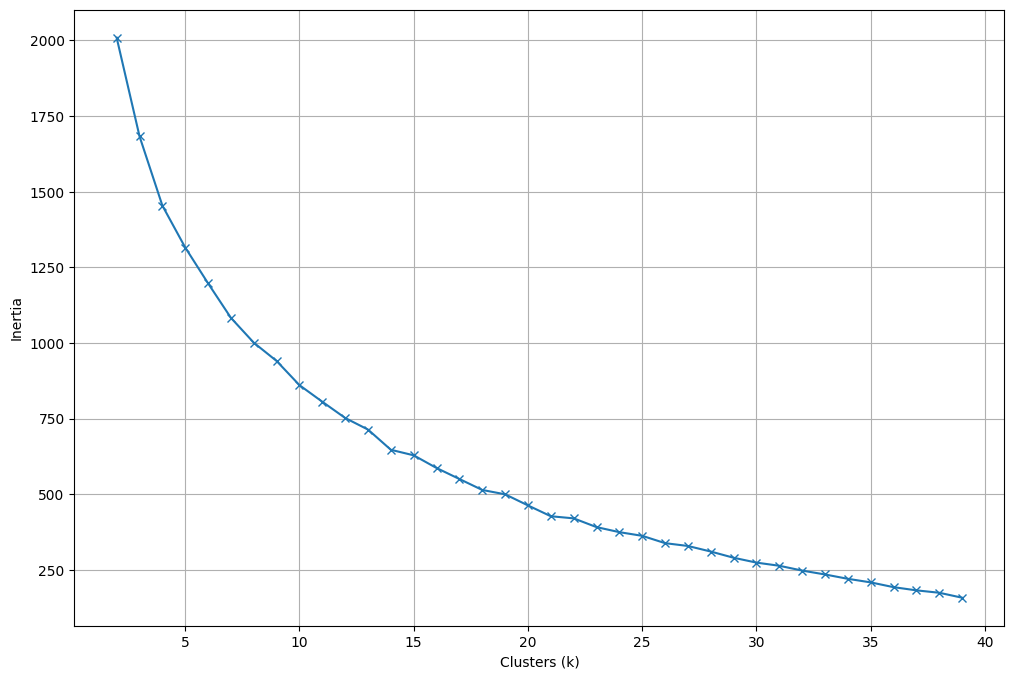

In [10]:
inertia = []
k_range = range(2, 40)
for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=rs)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(12, 8))
plt.plot(k_range, inertia, marker='x', color='tab:blue')
plt.xlabel('Clusters (k)')
plt.ylabel('Inertia')
plt.grid()
plt.show()

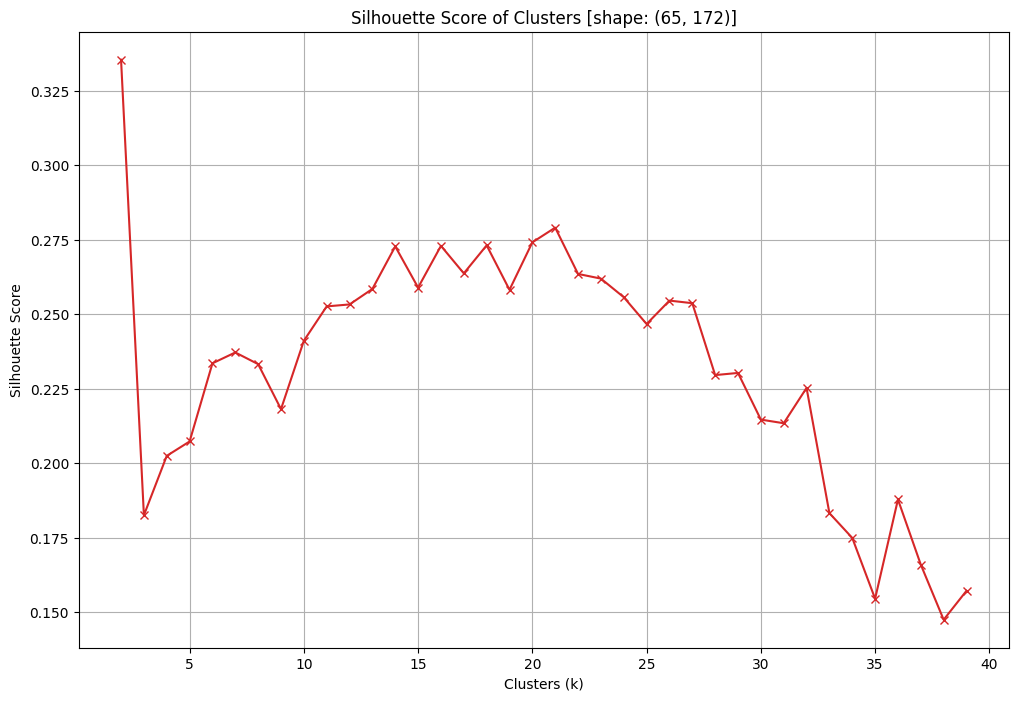

Top 5 optimal-k candidates:
k = 2 (0.3354)
k = 21 (0.2791)
k = 20 (0.2742)
k = 18 (0.2732)
k = 16 (0.2730)


In [13]:
silhouettes = []
for k in range(2, 40):
    kmeans = KMeans(n_clusters=k, random_state=rs, n_init=10)
    kmeans.fit(X)
    silhouettes.append(metrics.silhouette_score(X, kmeans.labels_))

plt.figure(figsize=(12, 8))
plt.plot(k_range, silhouettes, marker='x', color='tab:red')
plt.xlabel('Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score of Clusters [shape: (65, 172)]')
plt.grid()
plt.show()

print("Top 5 optimal-k candidates:")
for idx in np.argsort(silhouettes)[-5:][::-1]:
    print(f"k = {k_range[idx]} ({silhouettes[idx]:.4f})")